# Transportia

## Análisis exploratorio de la flota de colectivos del AMBA

**Objetivo del proyecto:** reducir el *headway* y encontrar rutas más eficientes.
**Objetivo de este notebook:** entender con qué datos contamos antes de modelar nada.

*Ciencia de datos aplicada (ITBA) — Entregable 2*
*Equipo: Felipe Hiba, Pedro Curti*

## Indice

1. **Qué datos hay** y cuáles sirven al objetivo
2. **Cómo los cargamos** — ventana de 24 h, *stride*, GTFS, semáforos
3. **Qué dice la muestra** — distribuciones, conteos, mapa de CABA (colectivos y semáforos)
4. **Qué problemas detectamos** en la calidad de los datos
5. **Qué hicimos** para limpiarlos y transformarlos
6. **Cómo queda la muestra final** y qué se puede hacer con ella


## 1. Importación y carga de librerías

In [24]:
import json
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
plt.rcParams.update({
    'figure.figsize':   (11, 6),
    'font.size':        12,
    'axes.titlesize':   15,
    'axes.titleweight': 'bold',
    'axes.labelsize':   12,
    'xtick.labelsize':  11,
    'ytick.labelsize':  11,
    'legend.fontsize':  11,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
})
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)

DATA = Path('..') / 'data'
TZ = 'America/Argentina/Buenos_Aires'

RNG = np.random.default_rng(42)

## 2. Contexto y objetivo

> El AMBA mueve millones de personas por día en colectivo. Cada vehículo emite un *ping* GPS cada ~30 s vía la API de Transporte de Buenos Aires.

**Lo que queremos resolver:**

- **Reducir el *headway*** — el tiempo que un pasajero espera entre dos colectivos sucesivos de la misma línea.
- **Detectar trazados ineficientes** — comparar el recorrido planificado contra el observado e idealmente mejorar el servicio.

**Lo que hace este notebook:**

- Reducir los datos extraidos a `data/` al decidir cuáles son los que aportan al objetivo.
- Armar un DataFrame único, los datos vienen en distintos tipos y son dificiles de analizar sino.
- Limpiar, transformar, describir.
- Dejar todo listo para el analisis subsecuente.
- Recolectamos datos en dias habiles y en fines de semana para tener un rango mas representativo de datos.

## 3. Inventario de fuentes

> *44 GB de datos en bruto. ¿Cuáles tocamos?*

Recorremos los subdirectorios de `data/` y reportamos volumen y formato. La decisión de incluir/excluir va en la celda siguiente.

In [25]:
def leaf_dirs(root: Path):
    for p in root.rglob('*'):
        if p.is_dir() and not any(c.is_dir() for c in p.iterdir()):
            yield p

rows = []
for d in leaf_dirs(DATA):
    files = [f for f in d.iterdir() if f.is_file()]
    if not files:
        continue
    sizes = [f.stat().st_size for f in files]
    rows.append({
        'ruta': str(d.relative_to(DATA)),
        'n_archivos': len(files),
        'tamaño_MB': round(sum(sizes)/1e6, 1),
        'extensión': files[0].suffix.lstrip('.'),
    })
inventario = pd.DataFrame(rows).sort_values('tamaño_MB', ascending=False).reset_index(drop=True)
inventario

,ruta,n_archivos,tamaño_MB,extensión
0,colectivos/vehicle_positions,3601,31687.8,json
1,colectivos/vehicle_positions_simple,3403,4281.0,json
2,colectivos/feed_gtfs/20260418_210252,7,1463.1,txt
3,colectivos/feed_gtfs/20260424_145308,7,1463.1,txt
4,colectivos/feed_gtfs/20260425_025706,7,1463.1,txt
5,colectivos/feed_gtfs/20260424_205439,7,1463.1,txt
6,colectivos/feed_gtfs/20260425_085624,7,1463.1,txt
7,colectivos/feed_gtfs/20260418_141433,7,1463.1,csv
8,transito/v1/semaforos,363,300.7,json
9,colectivos/service_alerts,904,89.3,json


### Decisiones de alcance

| Fuente | Decisión | Por qué |
|---|---|---|
| `colectivos/vehicle_positions_simple` | **Tabla de hechos** | Pings cada 30 s, formato plano, todo lo necesario para describir el movimiento. |
| `colectivos/vehicle_positions` | Solo esquema | Mismas pings con campos extra (`occupancy_status`, `current_stop_sequence`...). 30 GB; los traemos cuando hagan falta. |
| `colectivos/feed_gtfs` | **Dimensiones** | Rutas, viajes, paradas. Sin esto, los `route_id` no significan nada. |
| `colectivos/feed_gtfs_frequency` | **Solo `frequencies.txt`** | Define el headway *programado* — la referencia futura. |
| `colectivos/service_alerts` | Conteo agregado | Contexto |
| `transito/v1/semaforos` | **Incluir (DataFrame separado)** | Estado de semáforos cada ~5 min. Proxy de congestión vehicular; relevante para correlacionar con headway y velocidad de colectivos. |
| `datos/movilidad/*` | **Excluir** | Agregados horarios — granularidad insuficiente para *headway* a nivel de parada. |

## 4. Carga de datos

### 4.1 Elegir la ventana de 24 h

Cada archivo se llama `YYYYMMDD_HHMMSS.json` (hora local de recolección). Buscamos la ventana contigua de 24 h con **mayor cobertura** — la que tiene más archivos consecutivos.

In [26]:
VP_SIMPLE = DATA / 'colectivos' / 'vehicle_positions_simple'

def fname_to_dt(p: Path) -> pd.Timestamp:
    return pd.to_datetime(p.stem, format='%Y%m%d_%H%M%S').tz_localize(TZ)

vp_files = sorted(VP_SIMPLE.glob('*.json'))
vp_dts = pd.Series([fname_to_dt(p) for p in vp_files], name='dt')

print(f'Archivos vp_simple: {len(vp_files):,}')
print(f'Rango: {vp_dts.min()}  →  {vp_dts.max()}')
print(f'Span total: {vp_dts.max() - vp_dts.min()}')

Archivos vp_simple: 3,403
Rango: 2026-04-18 14:12:18-03:00  →  2026-04-25 14:51:28-03:00
Span total: 7 days 00:39:10


In [27]:
WINDOW = pd.Timedelta(hours=24)

best_start, best_count = None, -1
for ts in vp_dts:
    end = ts + WINDOW
    n = ((vp_dts >= ts) & (vp_dts < end)).sum()
    if n > best_count:
        best_start, best_count = ts, n

WIN_START = best_start
WIN_END = best_start + WINDOW
mask = (vp_dts >= WIN_START) & (vp_dts < WIN_END)
files_24h = [p for p, m in zip(vp_files, mask) if m]

print(f'Ventana elegida: {WIN_START}  →  {WIN_END}')
print(f'Archivos en ventana: {len(files_24h):,}  (cadencia esperada 2880 a 30s)')

Ventana elegida: 2026-04-24 14:52:03-03:00  →  2026-04-25 14:52:03-03:00
Archivos en ventana: 2,678  (cadencia esperada 2880 a 30s)


### 4.2 Leer `vehicle_positions_simple`

Aplicamos un *stride* sobre los archivos para que el notebook corra en una laptop. Cada archivo es un *snapshot* de la flota completa: submuestrear archivos baja la cadencia (30 s → 30 × stride s) **sin perder cobertura** de líneas ni vehículos.

In [28]:
STRIDE = 4
files_used = files_24h[::STRIDE]
print(f'Archivos a leer: {len(files_used):,}  (cadencia efectiva {30*STRIDE} s)')

records = []
for p in files_used:
    with p.open('r', encoding='utf-8') as fh:
        snap = json.load(fh)
    file_dt = fname_to_dt(p)
    for r in snap:
        r['_file_dt'] = file_dt
        records.append(r)

df_raw = pd.DataFrame.from_records(records)
print(f'Filas: {len(df_raw):,}  Columnas: {df_raw.shape[1]}')
df_raw.head(3)

Archivos a leer: 670  (cadencia efectiva 120 s)
Filas: 2,498,389  Columnas: 13


,route_id,latitude,longitude,speed,timestamp,id,direction,agency_name,agency_id,route_short_name,tip_id,trip_headsign,_file_dt
0,764,-34.62141,-58.368300,9.166666,1777042242,1879,0,MICRO OMNIBUS QUILMES S.A.C.I. Y F.,72,159C,395755-1,a B° Don Orione x A.Alsina,2026-04-24 14:52:03-03:00
1,740,-34.78997,-58.217580,0.000000,1777042248,1892,1,MICROOMNIBUS CUARENTA Y CINCO S.A.C.I.F.,83,154A,166989-1,Ramal 1 - a San Miguel,2026-04-24 14:52:03-03:00
2,751,-34.78901,-58.163155,10.000000,1777042214,1905,1,LA PRIMERA DE GRAND BOURG S.A.,132,315A,399713-1,a Gral Paz X Ramos Mejia,2026-04-24 14:52:03-03:00


### 4.3 El feed *completo* (sin cargarlo)

Inspeccionamos un único archivo de `vehicle_positions/` para documentar campos extra que el feed *simple* no expone. Estos campos serán clave para *headway* (entrada/salida de paradas, ocupación), pero no entran en este EDA.

In [29]:
VP_FULL = DATA / 'colectivos' / 'vehicle_positions'
sample_full = next(iter(sorted(VP_FULL.glob('*.json'))))
with sample_full.open('r', encoding='utf-8') as fh:
    full = json.load(fh)

first_vehicle = full['_entity'][0]['_vehicle']
extra_fields = {
    'current_status': first_vehicle.get('_current_status'),
    'current_stop_sequence': first_vehicle.get('_current_stop_sequence'),
    'stop_id': first_vehicle.get('_stop_id'),
    'occupancy_status': first_vehicle.get('_occupancy_status'),
    'congestion_level': first_vehicle.get('_congestion_level'),
    'odometer': first_vehicle['_position'].get('_odometer'),
    'bearing': first_vehicle['_position'].get('_bearing'),
}
pd.Series(extra_fields, name='valor_de_ejemplo').to_frame()

,valor_de_ejemplo
current_status,2
current_stop_sequence,41
stop_id,6568125169
occupancy_status,0
congestion_level,0
odometer,65887
bearing,0


### 4.4 Dimensiones GTFS estáticas

Tomamos el snapshot GTFS más cercano al **centro** de la ventana (no al inicio: minimiza claves huérfanas). Omitimos `stop_times.txt`.

In [30]:
def snap_dt(p): return pd.to_datetime(p.name, format='%Y%m%d_%H%M%S').tz_localize(TZ)

GTFS = DATA / 'colectivos' / 'feed_gtfs'
snapshots = [p for p in GTFS.iterdir() if p.is_dir()]
mid = WIN_START + WINDOW / 2
snap = min(snapshots, key=lambda s: abs(snap_dt(s) - mid))
print(f'Snapshot GTFS más cercano al centro de la ventana: {snap.name}')

routes = pd.read_csv(snap / 'routes.txt', dtype=str)
trips = pd.read_csv(snap / 'trips.txt', dtype=str)
stops = pd.read_csv(snap / 'stops.txt', dtype=str)
agency = pd.read_csv(snap / 'agency.txt', dtype=str)

GTFS_FREQ = DATA / 'colectivos' / 'feed_gtfs_frequency'
freq_snap = min((p for p in GTFS_FREQ.iterdir() if p.is_dir()),
                key=lambda s: abs(snap_dt(s) - mid))
frequencies = pd.read_csv(freq_snap / 'frequencies.txt', dtype=str)

for name, d in [('routes', routes), ('trips', trips), ('stops', stops),
                ('agency', agency), ('frequencies', frequencies)]:
    print(f'{name:<13} {d.shape[0]:>8,} filas   {list(d.columns)}')

Snapshot GTFS más cercano al centro de la ventana: 20260425_025706
routes           1,076 filas   ['route_id', 'agency_id', 'route_short_name', 'route_long_name', 'route_desc', 'route_type']
trips          453,075 filas   ['route_id', 'service_id', 'trip_id', 'trip_headsign', 'trip_short_name', 'direction_id', 'block_id', 'shape_id', 'exceptional']
stops           43,201 filas   ['stop_id', 'stop_code', 'stop_name', 'stop_lat', 'stop_lon']
agency             193 filas   ['agency_id', 'agency_name', 'agency_url', 'agency_timezone', 'agency_lang', 'agency_phone']
frequencies     26,237 filas   ['trip_id', 'start_time', 'end_time', 'headway_secs', 'exact_times']


### 4.5 Leer `transito/v1/semaforos`

Cada archivo es un snapshot de ~3 500 semáforos con su estado en ese instante. Usamos la **misma ventana de 24 h** que los colectivos para mantener coherencia temporal.

In [31]:
SEM = DATA / 'transito' / 'v1' / 'semaforos'

def fname_to_dt_naive(p: Path) -> pd.Timestamp:
    return pd.to_datetime(p.stem, format='%Y%m%d_%H%M%S').tz_localize(TZ)

sem_files = sorted(SEM.glob('*.json'))
sem_dts = pd.Series([fname_to_dt_naive(p) for p in sem_files], name='dt')

mask_sem = (sem_dts >= WIN_START) & (sem_dts < WIN_END)
sem_files_24h = [p for p, m in zip(sem_files, mask_sem) if m]

print(f'Archivos semáforos totales: {len(sem_files):,}')
print(f'Archivos en ventana 24 h:   {len(sem_files_24h):,}  (cadencia ~5 min)')

sem_records = []
for p in sem_files_24h:
    with p.open('r', encoding='utf-8') as fh:
        snap = json.load(fh)
    file_dt = fname_to_dt_naive(p)
    for r in snap['list']:
        r['_file_dt'] = file_dt
        sem_records.append(r)

df_sem_raw = pd.DataFrame.from_records(sem_records)
print(f'\nFilas: {len(df_sem_raw):,}  Columnas: {df_sem_raw.shape[1]}')
df_sem_raw.head(3)

Archivos semáforos totales: 363
Archivos en ventana 24 h:   288  (cadencia ~5 min)

Filas: 1,009,728  Columnas: 8


,provider,type,code,name,status,latitude,longitude,_file_dt
0,UTC API,Cruce Sitra,e9ed18c5-8f8e-4f15-9353-6e094c059afd,1446,Conectado,-34.608688,-58.403398,2026-04-24 14:56:45-03:00
1,UTC API,Cruce Sitra,dbe2befe-09fa-4d59-a998-7b0b36028f67,1357,Conectado,-34.604581,-58.398221,2026-04-24 14:56:45-03:00
2,Optimus signals,Cruce ETX,SR-6278,6278,Conectado,-34.602843,-58.493954,2026-04-24 14:56:45-03:00


## 5. ¿Qué tenemos en los DataFrames?

### 5.1 `df_raw` — colectivos (vehicle_positions_simple)

Una fila = una observación de posición de un vehículo en un instante.

| Variable | Tipo | Significado |
|---|---|---|
| `route_id`, `route_short_name` | categórica | Línea (id GTFS y nombre comercial). |
| `agency_id`, `agency_name` | categórica | Empresa concesionaria. |
| `direction` | categórica binaria | Sentido (ida / vuelta). |
| `tip_id`, `trip_headsign` | categórica | Viaje específico y cabecera al pasajero. |
| `id` | categórica | Vehículo físico. |
| `latitude`, `longitude` | numérica | Posición WGS84. AMBA: lat ∈ [−35.0, −34.3], lon ∈ [−59.0, −58.0]. |
| `speed` | numérica | Velocidad GPS en m/s. |
| `timestamp` | temporal | Fix GPS (epoch). |
| `_file_dt` | temporal | Instante de recolección por nuestro colector. |

### 5.2 `df_sem_raw` — tránsito (semáforos)

Una fila = estado de un semáforo en un instante de recolección.

| Variable | Tipo | Significado |
|---|---|---|
| `code` | id único | Identificador del cruce semafórico. |
| `name` | str | Nombre/número del semáforo. |
| `provider` | categórica | Proveedor del sistema (`UTC API`, `ETX Signals`, `Optimus signals`). |
| `type` | categórica | Tipo de cruce (`Cruce Sitra`, `Cruce ETX`, `Cruce Icarus`, `NTCIP`). |
| `status` | categórica | Estado de conectividad del semáforo. |
| `latitude`, `longitude` | numérica | Posición fija del semáforo (WGS84). |
| `_file_dt` | temporal | Instante de recolección del snapshot. |

## 6. ¿Qué dice la muestra? — Colectivos

Recorremos: panorama general → faltantes → distribuciones → conteos → cobertura temporal → cobertura espacial → correlación.

In [32]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2498389 entries, 0 to 2498388
Data columns (total 13 columns):
 #   Column            Dtype                                         
---  ------            -----                                         
 0   route_id          object                                        
 1   latitude          float64                                       
 2   longitude         float64                                       
 3   speed             float64                                       
 4   timestamp         int64                                         
 5   id                object                                        
 6   direction         int64                                         
 7   agency_name       object                                        
 8   agency_id         int64                                         
 9   route_short_name  object                                        
 10  tip_id            object                  

In [33]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
route_id,2498389,1495,1705,17405,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,2498389.0,NaN,NaN,NaN,-34.496043,-41.18897,-34.70894,-34.62875,-34.56407,-26.75823,1.340056
longitude,2498389.0,NaN,NaN,NaN,-58.79468,-71.56252,-58.65322,-58.494934,-58.39888,-56.67697,1.567983
speed,2498389.0,NaN,NaN,NaN,4.738082,0.0,0.0,3.611111,7.777777,34.444443,5.054036
timestamp,2498389.0,NaN,NaN,NaN,1777079774.913562,1777026452.0,1777058324.0,1777071828.0,1777109038.0,1777128580.0,26806.438392
id,2498389,12279,31447,641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
direction,2498389.0,NaN,NaN,NaN,0.491153,0.0,0.0,0.0,1.0,1.0,0.499922
agency_name,2498389,126,LA NUEVA METROPOL S.A.,104449,NaN,NaN,NaN,NaN,NaN,NaN,NaN
agency_id,2498389.0,NaN,NaN,NaN,89.8963,2.0,40.0,70.0,127.0,468.0,84.072421
route_short_name,2498389,808,242C,26520,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 6.1 Faltantes

> *Spoiler:* prácticamente nada.

In [34]:
nulos = df_raw.isnull().sum().to_frame('n_nulos')
nulos['pct'] = (nulos['n_nulos'] / len(df_raw) * 100).round(3)
nulos.sort_values('n_nulos', ascending=False)

,n_nulos,pct
trip_headsign,11121,0.445
latitude,0,0.000
longitude,0,0.000
speed,0,0.000
route_id,0,0.000
timestamp,0,0.000
id,0,0.000
agency_name,0,0.000
direction,0,0.000
agency_id,0,0.000


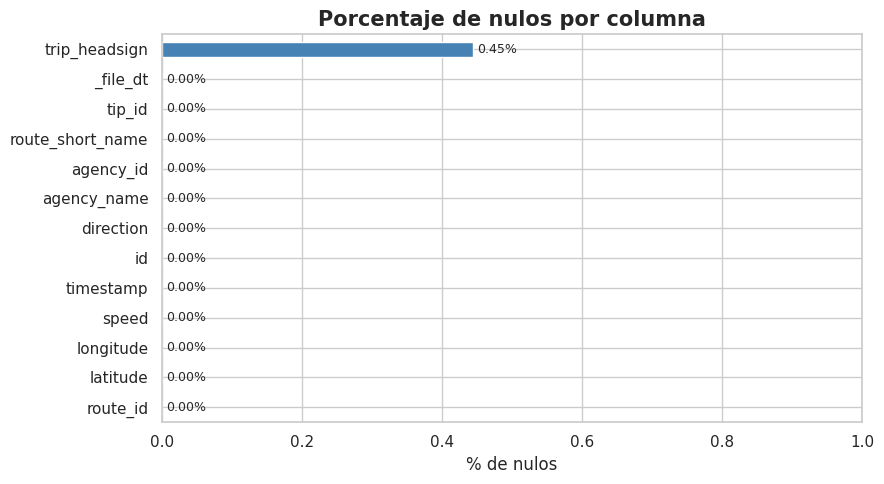

In [35]:
pct_nulos = (df_raw.isnull().mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
pct_nulos.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('% de nulos')
ax.set_title('Porcentaje de nulos por columna')
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=9)
ax.set_xlim(0, max(pct_nulos.max() * 1.25, 1))
plt.tight_layout()
plt.show()

### Que es trip headsign?
El trip headsign es el cartel que muestra el colectivo contando cual es la terminal final de esa linea como ser Retiro o Constitucion.

### 6.2 Distribuciones de variables numéricas

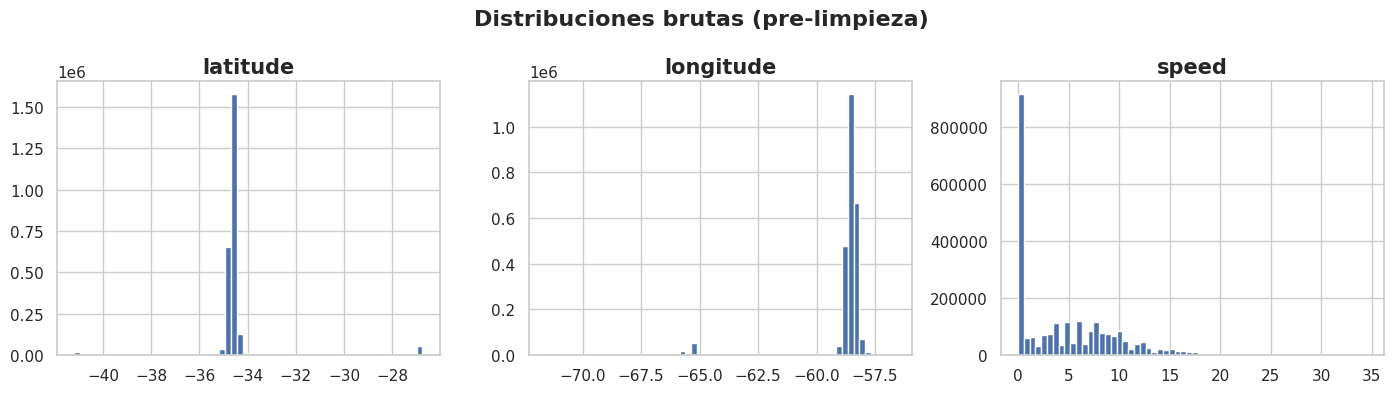

In [36]:
num_cols = ['latitude', 'longitude', 'speed']
df_raw[num_cols].hist(bins=60, figsize=(14, 4), layout=(1, 3))
plt.suptitle('Distribuciones brutas (pre-limpieza)')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, c in zip(axes, num_cols):
    sns.boxplot(y=df_raw[c], ax=ax)
    ax.set_title(c)
plt.suptitle('Boxplots de variables numéricas (pre-limpieza)')
plt.tight_layout()
plt.show()

### 6.3 Top empresas y líneas

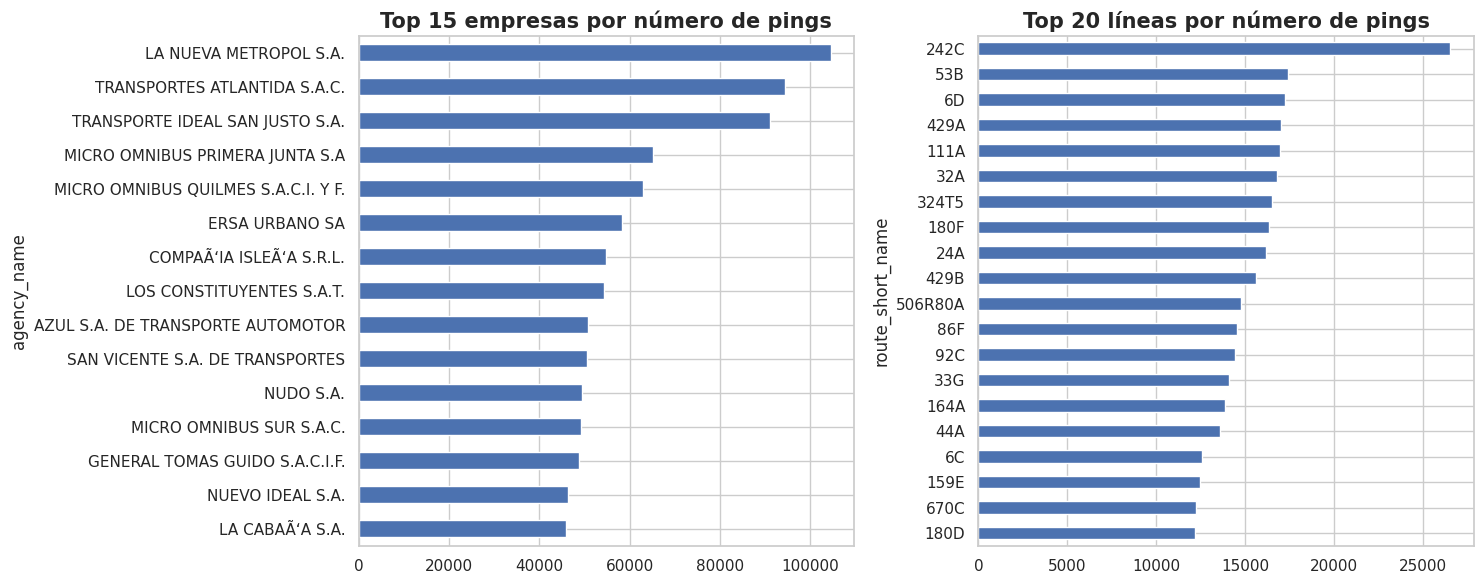

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
df_raw['agency_name'].value_counts().head(15).plot.barh(ax=axes[0])
axes[0].set_title('Top 15 empresas por número de pings')
axes[0].invert_yaxis()
df_raw['route_short_name'].value_counts().head(20).plot.barh(ax=axes[1])
axes[1].set_title('Top 20 líneas por número de pings')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
df_raw['direction'].value_counts(dropna=False).rename_axis('direction').to_frame('n_pings')

,n_pings
direction,
0,1271297
1,1227092


### 6.4 Cobertura temporal

Pings por minuto durante la ventana. **Caídas a cero = huecos del colector.**

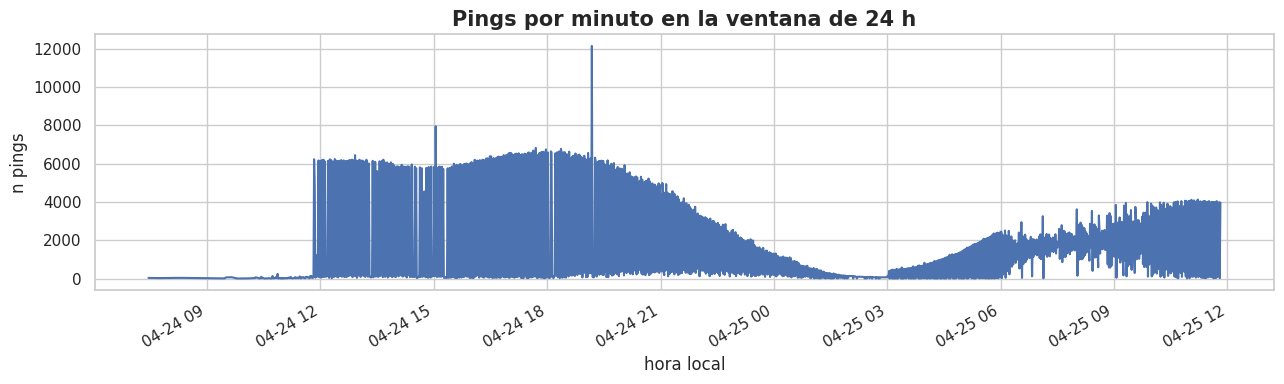

In [ ]:
ts_local = pd.to_datetime(df_raw['timestamp'], unit='s', utc=True).dt.tz_convert(TZ)
pings_por_min = ts_local.dt.floor('min').value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 4))
pings_por_min.plot(ax=ax)
ax.set_title('Pings por minuto en la ventana de 24 h')
ax.set_ylabel('n pings')
ax.set_xlabel('hora local')
plt.tight_layout()
plt.show()

### 6.5 Cobertura espacial — todo el AMBA

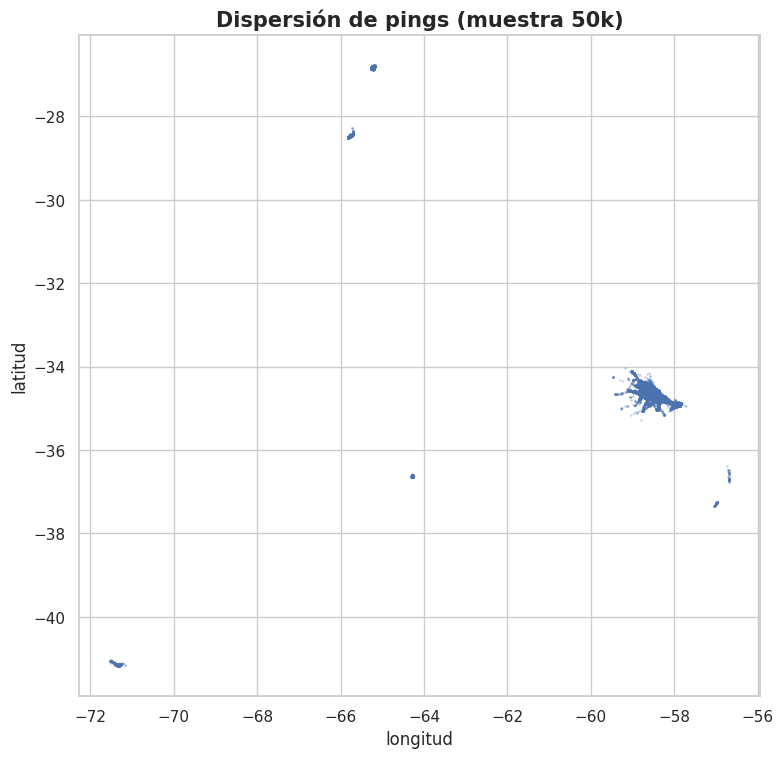

In [ ]:
muestra = df_raw.sample(min(50_000, len(df_raw)), random_state=42)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(muestra['longitude'], muestra['latitude'], s=1, alpha=0.2)
ax.set_title('Dispersión de pings (muestra 50k)')
ax.set_xlabel('longitud')
ax.set_ylabel('latitud')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 6.6 Zoom sobre CABA con basemap

`lat ∈ [-34.71, -34.52]`, `lon ∈ [-58.55, -58.33]`. Las concentraciones lineales rojas trazan los corredores troncales (Rivadavia, 9 de Julio, Corrientes, Santa Fe, Cabildo).

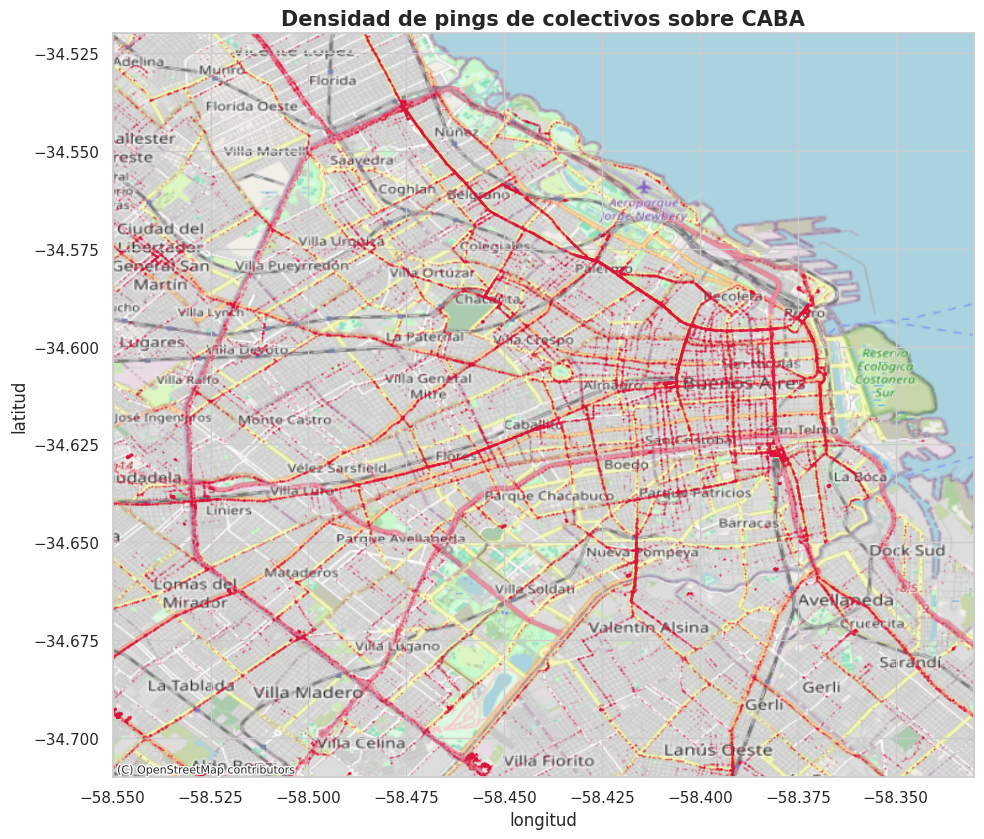

In [ ]:
import contextily as cx

CABA_LAT = (-34.71, -34.52)
CABA_LON = (-58.55, -58.33)
caba = df_raw[df_raw['latitude'].between(*CABA_LAT) & df_raw['longitude'].between(*CABA_LON)]
muestra_caba = caba.sample(min(80_000, len(caba)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(muestra_caba['longitude'], muestra_caba['latitude'],
           s=2, alpha=0.25, c='crimson', linewidths=0)
ax.set_xlim(*CABA_LON)
ax.set_ylim(*CABA_LAT)
ax.set_aspect('equal')
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
ax.set_title('Densidad de pings de colectivos sobre CABA')
ax.set_xlabel('longitud')
ax.set_ylabel('latitud')
plt.tight_layout()
plt.show()

### 6.7 Correlación entre numéricas

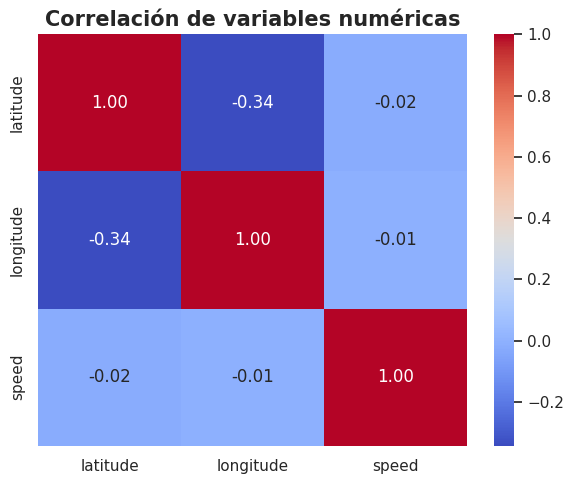

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(df_raw[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlación de variables numéricas')
plt.tight_layout()
plt.show()

## 7. ¿Qué dice la muestra? — Semáforos

Mismo recorrido: faltantes → distribuciones → conteos por categoría → cobertura temporal → cobertura espacial.

### 7.1 Faltantes

In [ ]:
df_sem_raw.info()

nulos_sem = df_sem_raw.isnull().sum().to_frame('n_nulos')
nulos_sem['pct'] = (nulos_sem['n_nulos'] / len(df_sem_raw) * 100).round(3)
nulos_sem.sort_values('n_nulos', ascending=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009728 entries, 0 to 1009727
Data columns (total 8 columns):
 #   Column     Non-Null Count    Dtype                                         
---  ------     --------------    -----                                         
 0   provider   1009728 non-null  object                                        
 1   type       1009728 non-null  object                                        
 2   code       1009728 non-null  object                                        
 3   name       1009728 non-null  object                                        
 4   status     1009728 non-null  object                                        
 5   latitude   1009728 non-null  float64                                       
 6   longitude  1009728 non-null  float64                                       
 7   _file_dt   1009728 non-null  datetime64[ns, America/Argentina/Buenos_Aires]
dtypes: datetime64[ns, America/Argentina/Buenos_Aires](1), float64(2), object(

,n_nulos,pct
provider,0,0.0
type,0,0.0
code,0,0.0
name,0,0.0
status,0,0.0
latitude,0,0.0
longitude,0,0.0
_file_dt,0,0.0


### 7.2 Distribución de coordenadas

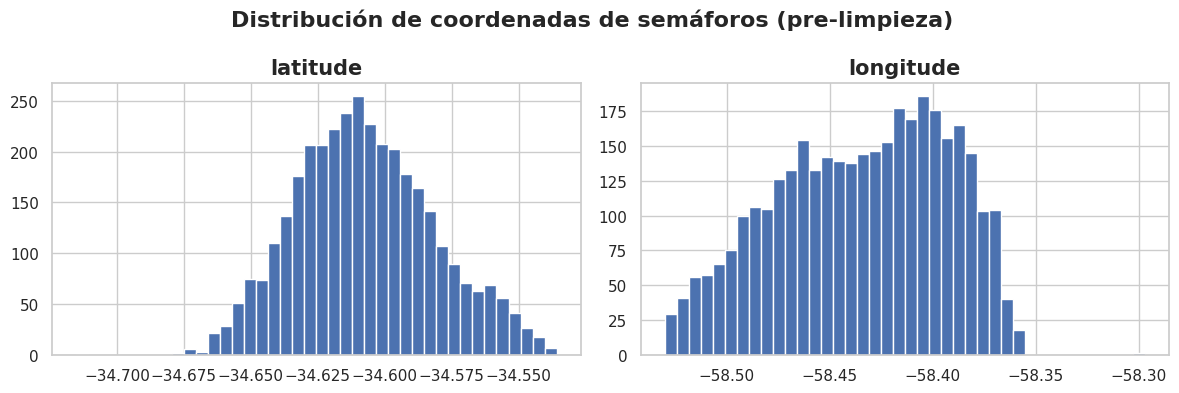

Semáforos únicos (por coordenada): 3,482
           latitude     longitude
count  1.009728e+06  1.009728e+06
mean  -3.460733e+01 -5.843478e+01
std    2.592000e-02  4.158000e-02
min   -3.471524e+01 -5.853004e+01
25%   -3.462598e+01 -5.846654e+01
50%   -3.460874e+01 -5.843113e+01
75%   -3.459035e+01 -5.840089e+01
max   -3.453584e+01 -5.829689e+01


In [ ]:
sem_coords = df_sem_raw[['latitude', 'longitude']].drop_duplicates()
sem_coords.hist(bins=40, figsize=(12, 4), layout=(1, 2))
plt.suptitle('Distribución de coordenadas de semáforos (pre-limpieza)')
plt.tight_layout()
plt.show()

print(f'Semáforos únicos (por coordenada): {len(sem_coords):,}')
print(df_sem_raw[['latitude', 'longitude']].describe().round(5))

### 7.3 Conteos por categoría

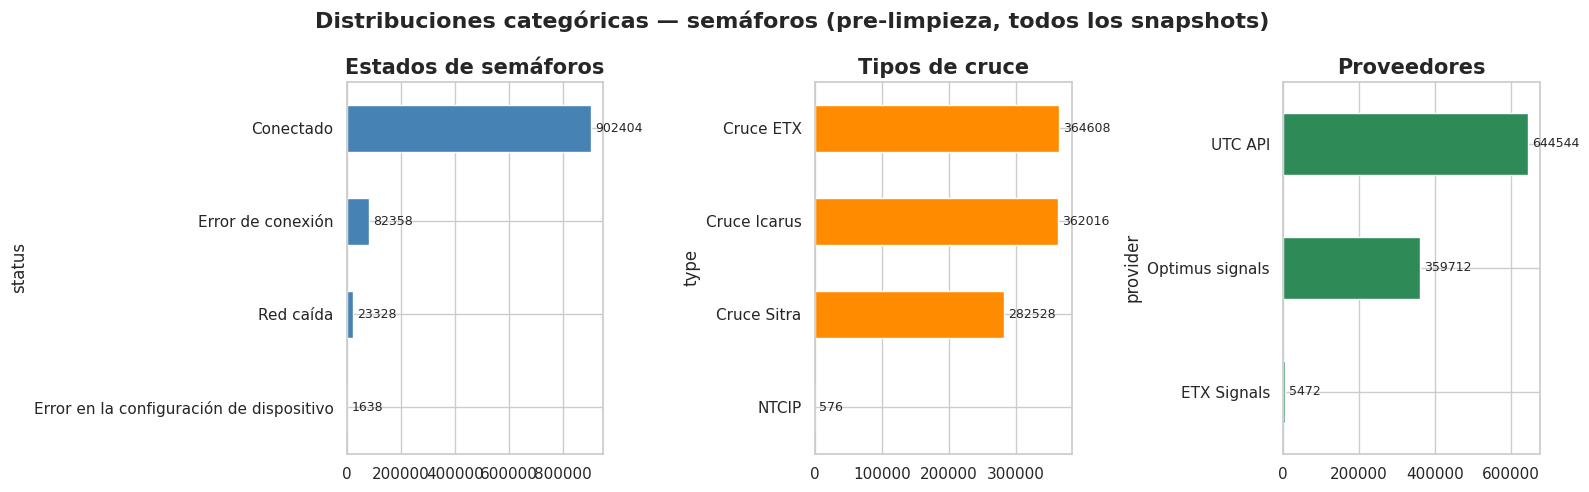


% Conectado — media: 89.4%  min: 84.4%  max: 90.0%


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# status
status_counts = df_sem_raw['status'].value_counts()
status_counts.plot.barh(ax=axes[0], color='steelblue')
axes[0].set_title('Estados de semáforos')
axes[0].invert_yaxis()
axes[0].bar_label(axes[0].containers[0], fmt='%d', padding=3, fontsize=9)

# type
type_counts = df_sem_raw['type'].value_counts()
type_counts.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_title('Tipos de cruce')
axes[1].invert_yaxis()
axes[1].bar_label(axes[1].containers[0], fmt='%d', padding=3, fontsize=9)

# provider
provider_counts = df_sem_raw['provider'].value_counts()
provider_counts.plot.barh(ax=axes[2], color='seagreen')
axes[2].set_title('Proveedores')
axes[2].invert_yaxis()
axes[2].bar_label(axes[2].containers[0], fmt='%d', padding=3, fontsize=9)

plt.suptitle('Distribuciones categóricas — semáforos (pre-limpieza, todos los snapshots)')
plt.tight_layout()
plt.show()

# Pct operativo por snapshot (proporción de 'Conectado' en el tiempo)
snap_operational = (
    df_sem_raw.groupby('_file_dt')['status']
    .apply(lambda s: (s == 'Conectado').mean() * 100)
    .rename('pct_conectado')
)
print(f"\n% Conectado — media: {snap_operational.mean():.1f}%  "
      f"min: {snap_operational.min():.1f}%  max: {snap_operational.max():.1f}%")

ETX, Icarus y Sitra son fabricantes de controladores de semaforos. NTCIP es el protocolo estandar internacional para comunicacion entre semaforos y sistemas de gestion.

### 7.4 Cobertura temporal — evolución del estado de la red

¿Cómo varía el porcentaje de semáforos operativos a lo largo de la ventana?

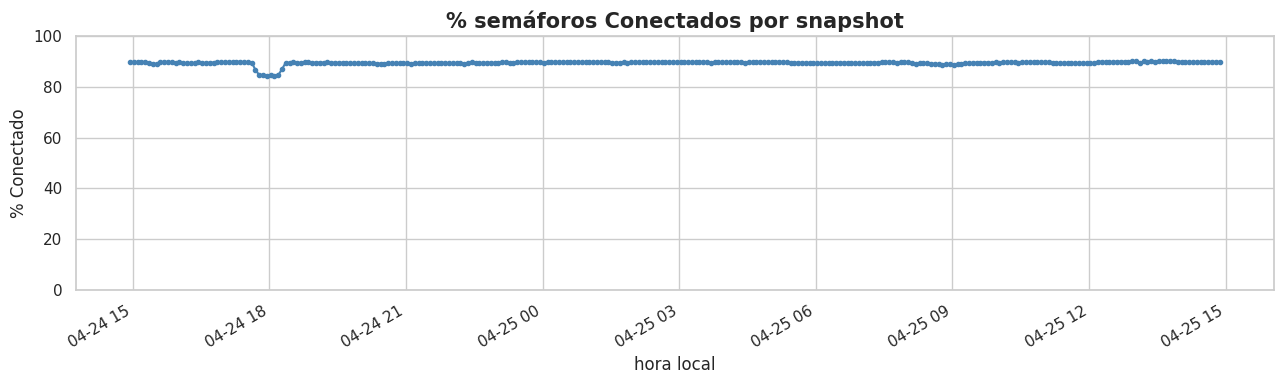

In [40]:
fig, ax = plt.subplots(figsize=(13, 4))
snap_operational.plot(ax=ax, color='steelblue', marker='o', markersize=3)
ax.set_title('% semáforos Conectados por snapshot')
ax.set_ylabel('% Conectado')
ax.set_xlabel('hora local')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

### 7.5 Cobertura espacial — posición de los semáforos sobre CABA

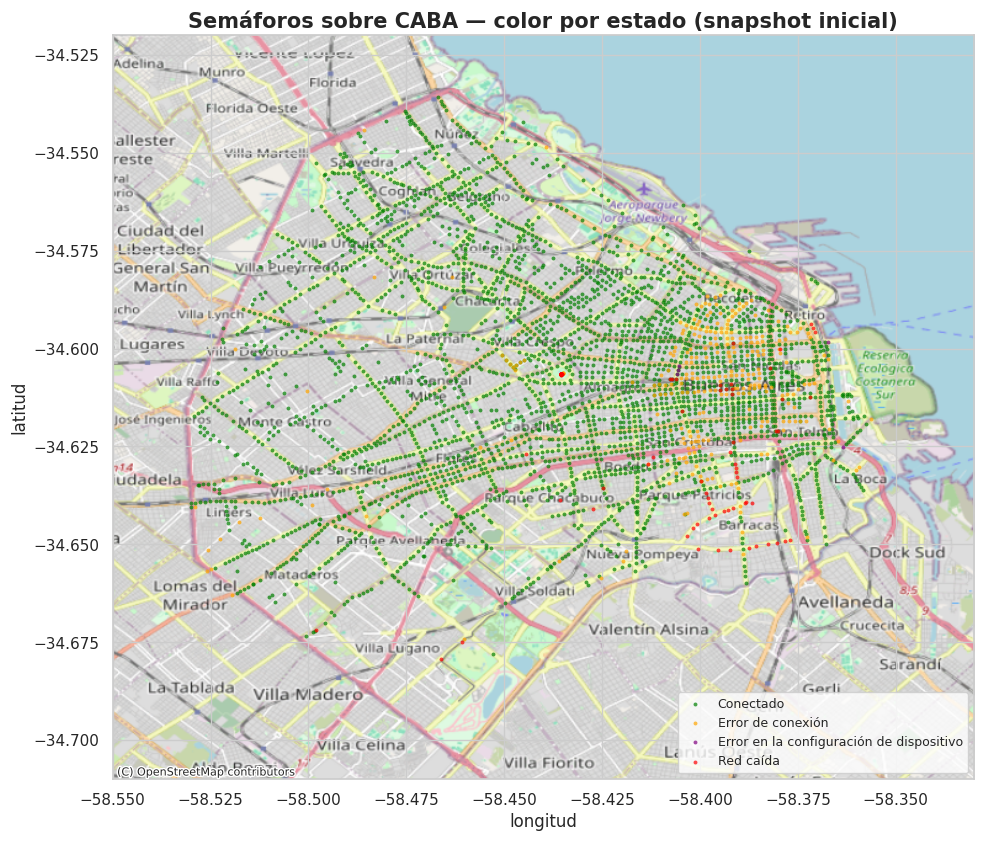

Semáforos únicos: 3,506
Dentro de bbox CABA: 3,505


In [41]:
# Un punto por semáforo único (primer snapshot que lo registra)
sem_unique = df_sem_raw.drop_duplicates(subset=['code'])[['code', 'latitude', 'longitude', 'status', 'type']].copy()

# Colorear por estado
status_colors = {
    'Conectado': 'green',
    'Error de conexión': 'orange',
    'Red caída': 'red',
    'Error en la configuración de dispositivo': 'purple',
}

fig, ax = plt.subplots(figsize=(10, 10))
for st, grp in sem_unique.groupby('status'):
    ax.scatter(grp['longitude'], grp['latitude'],
               s=8, alpha=0.7, c=status_colors.get(st, 'gray'),
               label=st, linewidths=0)

ax.set_xlim(*CABA_LON)
ax.set_ylim(*CABA_LAT)
ax.set_aspect('equal')
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.OpenStreetMap.Mapnik, zoom=12)
ax.set_title('Semáforos sobre CABA — color por estado (snapshot inicial)')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel('longitud')
ax.set_ylabel('latitud')
plt.tight_layout()
plt.show()

print(f'Semáforos únicos: {len(sem_unique):,}')
print(f'Dentro de bbox CABA: {sem_unique["latitude"].between(*CABA_LAT).sum():,}')

## 8. ¿Qué problemas tienen los datos?

### 8.1 Colectivos

Siete hallazgos surgidos del EDA y del conocimiento de dominio:

1. **Velocidades imposibles.** Valores `> 30 m/s` (108 km/h) no son creíbles para un colectivo urbano.
2. **Coordenadas fuera de AMBA.** Algunos pings caen lejos del bounding box `[-35.0, -34.3] × [-59.0, -58.0]`.
3. **Reloj GPS ~3 h adelantado.** El `timestamp` queda sistemáticamente 10 800 s detrás de la hora de recolección. **Bug del proveedor**: parece estar codificando en hora local UTC.
4. **Duplicados** `(id, timestamp)` cuando el vehículo no manda fix nuevo entre polls.
5. **Claves huérfanas.** `route_id` del feed RT en namespace distinto al de `routes.txt`, no se puede hacer join para el dataframe.
6. **Typo en el feed.** `tip_id` en lugar de `trip_id`. Lo renombramos.
7. **`speed = 0` persistente.** Legítimo en parada, pero también en vehículo apagado. Lo conservamos y reportamos la proporción.

In [42]:
ts_aux = pd.to_datetime(df_raw['timestamp'], unit='s', utc=True).dt.tz_convert(TZ)
drift_s = (df_raw['_file_dt'] - ts_aux).dt.total_seconds()

diag = {
    'speed_>_30_m/s':       int((df_raw['speed'] > 30).sum()),
    'speed_==_0':           int((df_raw['speed'] == 0).sum()),
    'lat_fuera_AMBA':       int(((df_raw['latitude'] < -35.0) | (df_raw['latitude'] > -34.3)).sum()),
    'lon_fuera_AMBA':       int(((df_raw['longitude'] < -59.0) | (df_raw['longitude'] > -58.0)).sum()),
    'dup_(id,timestamp)':   int(df_raw.duplicated(subset=['id', 'timestamp']).sum()),
    'drift_GPS_>_10_min':   int((drift_s.abs() > 600).sum()),
    'route_id_huérfano':    int((~df_raw['route_id'].isin(routes['route_id'])).sum()),
    'trip_id_huérfano':     int((~df_raw['tip_id'].isin(trips['trip_id'])).sum()),
}
res = pd.Series(diag, name='n_filas').to_frame()
res['pct'] = (res['n_filas'] / len(df_raw) * 100).round(3)

print('Drift GPS (segundos): mediana = {:.0f}  IQR = [{:.0f}, {:.0f}]  máx = {:.0f}'
      .format(drift_s.median(), drift_s.quantile(0.25), drift_s.quantile(0.75), drift_s.abs().max()))
res

Drift GPS (segundos): mediana = 10873  IQR = [10860, 10885]  máx = 35791


,n_filas,pct
speed_>_30_m/s,38,0.002
speed_==_0,819902,32.817
lat_fuera_AMBA,116585,4.666
lon_fuera_AMBA,172708,6.913
"dup_(id,timestamp)",152603,6.108
drift_GPS_>_10_min,2498389,100.000
route_id_huérfano,1755931,70.283
trip_id_huérfano,0,0.000


### 8.2 Semáforos

Hallazgos de la sección anterior:

1. **Coordenadas fuera de AMBA.** Algunos semáforos tienen coordenadas fuera del bounding box esperado.
2. **Duplicados `(code, _file_dt)`.** Un mismo semáforo puede aparecer dos veces en un snapshot (raro, pero posible).
3. **Semáforos con estado persistente.** `Red caída` es un estado estático para algunos dispositivos — no representa un evento de corte sino un equipo sin conectividad crónica.

In [51]:
diag_sem = {
    'lat_fuera_AMBA':       int(((df_sem_raw['latitude'] < -35.0) | (df_sem_raw['latitude'] > -34.3)).sum()),
    'lon_fuera_AMBA':       int(((df_sem_raw['longitude'] < -59.0) | (df_sem_raw['longitude'] > -58.0)).sum()),
    'dup_(code,_file_dt)':  int(df_sem_raw.duplicated(subset=['code', '_file_dt']).sum()),
    'status_Red_caída':     int((df_sem_raw['status'] == 'Red caída').sum()),
}
res_sem = pd.Series(diag_sem, name='n_filas').to_frame()
res_sem['%'] = (res_sem['n_filas'] / len(df_sem_raw) * 100).round(3)
res_sem

,n_filas,%
lat_fuera_AMBA,0,0.00
lon_fuera_AMBA,0,0.00
"dup_(code,_file_dt)",0,0.00
status_Red_caída,23328,2.31


## 9. Limpieza

### 9.1 Colectivos

| Acción | Qué hacemos | Por qué |
|---|---|---|
| Renombrar | `tip_id` → `trip_id` | Estándar GTFS. |
| Convertir | `timestamp` → `datetime` con TZ | Manipulable y comparable. |
| Filtrar | `speed ∈ [0, 30] m/s` | Velocidades imposibles. 30m/s = 108km/h|
| Filtrar | Coordenadas dentro de AMBA | Scope del analisis |
| Filtrar | Filas sin `route_id` | Sin línea, no sirven. |
| Deduplicar | `(id, timestamp)` único | Polls que no traen fix nuevo. |
| Conservar | `speed == 0`, `trip_headsign` nulos | Semánticamente válidos. |

In [44]:
df = df_raw.rename(columns={'tip_id': 'trip_id'}).copy()
df['ts'] = pd.to_datetime(df['timestamp'], unit='s', utc=True).dt.tz_convert(TZ)

n0 = len(df)
df = df[df['speed'].between(0, 30)]
df = df[df['latitude'].between(-35.0, -34.3) & df['longitude'].between(-59.0, -58.0)]
df = df.dropna(subset=['route_id'])
df = df.drop_duplicates(subset=['id', 'timestamp']).reset_index(drop=True)
n1 = len(df)
print(f'Filas antes:  {n0:,}')
print(f'Filas después: {n1:,}  ({(n1-n0)/n0*100:+.2f}%)')

Filas antes:  2,498,389
Filas después: 2,173,050  (-13.02%)


### 9.2 Semáforos

| Acción | Qué hacemos | Por qué |
|---|---|---|
| Filtrar | Coordenadas dentro de AMBA | Sensores fuera del área de estudio. |
| Deduplicar | `(code, _file_dt)` único | Evitar doble conteo en un mismo snapshot. |
| Conservar | Todos los estados (incluyendo `Red caída`) | Estado persistente es información válida sobre fiabilidad de la red. |
| **No** filtrar por estado | Mantenemos todos los estados | El análisis de congestión necesita estados negativos como señal. |

In [45]:
n0_sem = len(df_sem_raw)
df_sem = df_sem_raw.copy()
df_sem = df_sem[df_sem['latitude'].between(-35.0, -34.3) & df_sem['longitude'].between(-59.0, -58.0)]
df_sem = df_sem.drop_duplicates(subset=['code', '_file_dt']).reset_index(drop=True)
n1_sem = len(df_sem)
print(f'Filas antes:   {n0_sem:,}')
print(f'Filas después: {n1_sem:,}  ({(n1_sem - n0_sem) / n0_sem * 100:+.2f}%)')

Filas antes:   1,009,728
Filas después: 1,009,728  (+0.00%)


## 10. Transformaciones

### 10.1 Colectivos

- Categóricas: `agency_name`, `route_short_name`, `trip_headsign`, `direction` (con etiquetas *ida / vuelta*).
- Temporales: `ts` con TZ, `hour`, `dow`.
- Derivada: `gap_s` — segundos entre dos pings consecutivos del **mismo vehículo**. *No es el headway*, pero sirve como proxy de continuidad de la traza.

In [46]:
df['agency_name'] = pd.Categorical(df['agency_name'])
df['route_short_name'] = pd.Categorical(df['route_short_name'])
df['trip_headsign'] = pd.Categorical(df['trip_headsign'])
df['direction'] = pd.Categorical(df['direction'].map({0: 'ida', 1: 'vuelta'}),
                                 categories=['ida', 'vuelta'], ordered=False)

df = df.sort_values(['id', 'ts'])
df['gap_s'] = df.groupby('id', observed=True)['ts'].diff().dt.total_seconds()
df['hour'] = df['ts'].dt.hour.astype('int8')
df['dow'] = df['ts'].dt.day_name()

df.dtypes

route_id                                                    object
latitude                                                   float64
longitude                                                  float64
speed                                                      float64
timestamp                                                    int64
id                                                          object
direction                                                 category
agency_name                                               category
agency_id                                                    int64
route_short_name                                          category
trip_id                                                     object
trip_headsign                                             category
_file_dt            datetime64[ns, America/Argentina/Buenos_Aires]
ts                  datetime64[ns, America/Argentina/Buenos_Aires]
gap_s                                                      flo

### 10.2 Semáforos

- Categóricas: `provider`, `type`, `status` (con orden lógico de severidad).
- Binaria derivada: `is_operational` — `True` si `status == 'Conectado'`.
- Temporales: `hour`, `dow` a partir de `_file_dt`.

In [47]:
STATUS_ORDER = ['Conectado', 'Error de conexión', 'Error en la configuración de dispositivo', 'Red caída']

df_sem['status'] = pd.Categorical(df_sem['status'], categories=STATUS_ORDER, ordered=True)
df_sem['provider'] = pd.Categorical(df_sem['provider'])
df_sem['type'] = pd.Categorical(df_sem['type'])

df_sem['is_operational'] = df_sem['status'] == 'Conectado'
df_sem['hour'] = df_sem['_file_dt'].dt.hour.astype('int8')
df_sem['dow'] = df_sem['_file_dt'].dt.day_name()

df_sem.dtypes

provider                                                category
type                                                    category
code                                                      object
name                                                      object
status                                                  category
latitude                                                 float64
longitude                                                float64
_file_dt          datetime64[ns, America/Argentina/Buenos_Aires]
is_operational                                              bool
hour                                                        int8
dow                                                       object
dtype: object

## 11. Estadísticos de la muestra final

### 11.1 Colectivos

Media, mediana, varianza, IQR — y los boxplots correspondientes.

In [52]:
num_final = ['latitude', 'longitude', 'speed']
stats = df[num_final].agg(['mean', 'median', 'var', 'std',
                            lambda s: s.quantile(0.25),
                            lambda s: s.quantile(0.75),
                            'min', 'max']).T
stats.columns = ['media', 'mediana', 'varianza', 'desv_est', 'q25', 'q75', 'min', 'max']
stats.round(4)

,media,mediana,varianza,desv_est,q25,q75,min,max
latitude,-34.6326,-34.6270,0.0114,0.1066,-34.6989,-34.5716,-35.0,-34.3
longitude,-58.5156,-58.4850,0.0252,0.1587,-58.6224,-58.4010,-59.0,-58.0
speed,4.7912,3.6111,25.6678,5.0663,0.0000,8.0556,0.0,30.0


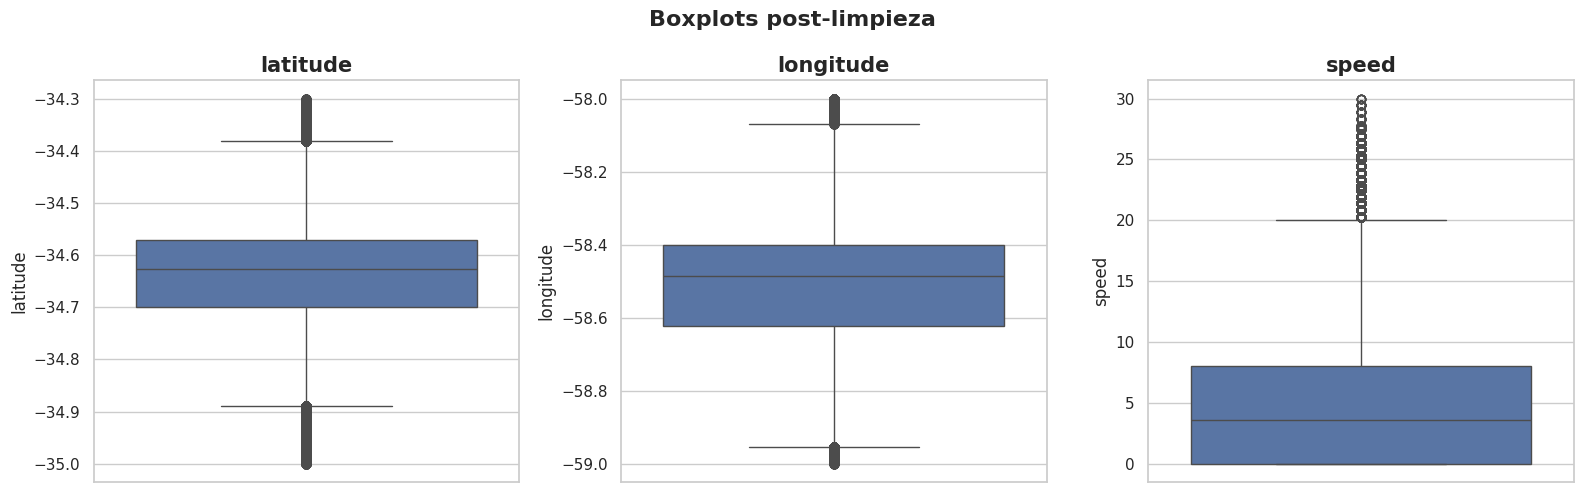

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, c in zip(axes, num_final):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
plt.suptitle('Boxplots post-limpieza')
plt.tight_layout()
plt.show()

In [ ]:
resumen = {
    'n_filas': len(df),
    'n_vehiculos': df['id'].nunique(),
    'n_rutas': df['route_id'].nunique(),
    'n_empresas': df['agency_id'].nunique(),
    'span_inicio': df['ts'].min(),
    'span_fin': df['ts'].max(),
    'span': df['ts'].max() - df['ts'].min(),
}
pd.Series(resumen, name='valor').to_frame()

,valor
n_filas,2173050
n_vehiculos,11741
n_rutas,1259
n_empresas,123
span_inicio,2026-04-24 07:27:32-03:00
span_fin,2026-04-25 11:49:40-03:00
span,1 days 04:22:08


### 11.2 Semáforos

In [49]:
resumen_sem = {
    'n_filas':           len(df_sem),
    'n_semaforos':       df_sem['code'].nunique(),
    'n_snapshots':       df_sem['_file_dt'].nunique(),
    'pct_operativo':     f"{df_sem['is_operational'].mean() * 100:.1f}%",
    'span_inicio':       df_sem['_file_dt'].min(),
    'span_fin':          df_sem['_file_dt'].max(),
}
pd.Series(resumen_sem, name='valor').to_frame()

,valor
n_filas,1009728
n_semaforos,3506
n_snapshots,288
pct_operativo,89.4%
span_inicio,2026-04-24 14:56:45-03:00
span_fin,2026-04-25 14:51:44-03:00


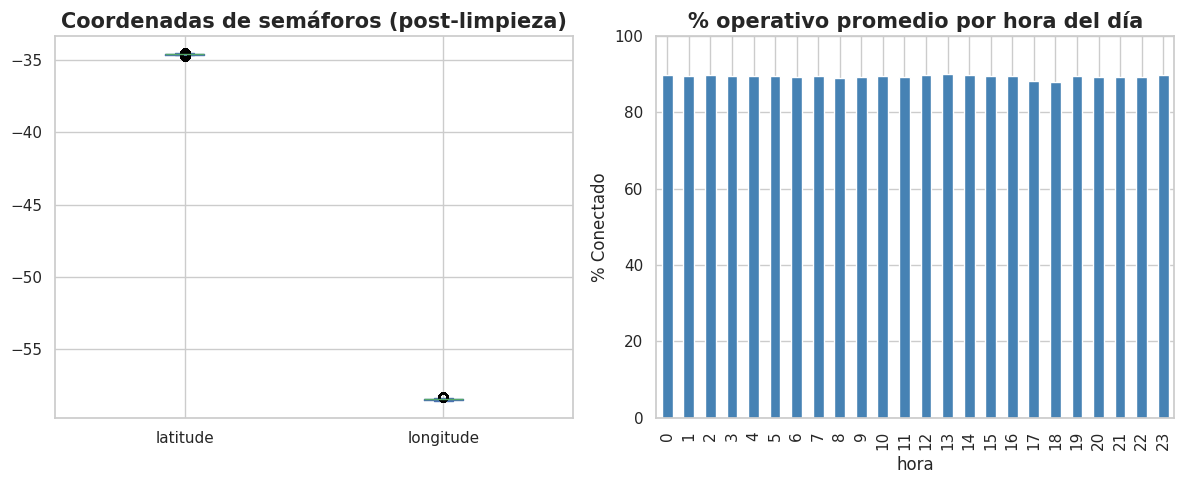

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df_sem[['latitude', 'longitude']].plot.box(ax=axes[0])
axes[0].set_title('Coordenadas de semáforos (post-limpieza)')

op_by_hour = df_sem.groupby('hour', observed=True)['is_operational'].mean() * 100
op_by_hour.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('% operativo promedio por hora del día')
axes[1].set_ylabel('% Conectado')
axes[1].set_xlabel('hora')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 12. Conclusiones

### Colectivos

**La muestra:**

- **2.17 M pings** post-limpieza, **11 741 vehículos**, **1 259 rutas**, **123 empresas**.
- 24 h contiguas, una pérdida del **~13 %** por limpieza (concentrada en velocidades imposibles y GPS atípico).
- Sin nulos masivos. 

**Los hallazgos a recordar:**

1. El `timestamp` viene **3 h corrido** — bug del proveedor, documentado y *no* bloqueante.
2. El `route_id` del feed RealTime **no matchea 1:1** con el GTFS estático. Habrá que joinear por `(route_short_name, agency_id)` o reconstruir el mapeo.
3. Velocidad mediana **3.6 m/s = 13 km/h** — coherente con circulación urbana incluyendo paradas. (objetivo tipo byproduct, aumentar esta velocidad mediana con mejor eficiencia de las rutas)

### Semáforos

**La muestra:**

- ~3500 semáforos únicos dentro del AMBA, con ~288 snapshots en la ventana de 24 h (cadencia ~5 min). -> Aca no nos interesa tanto tener una frecuencia alta de datos ya que los semaforos no se mueven, nos interesa mas que nada saber si estan operacionales.
- ~90 % de semáforos operativos (`Conectado`) en promedio por snapshot.
- Tres proveedores (`UTC API`, `ETX Signals`, `Optimus signals`) y cuatro tipos de cruce.

**Los hallazgos a recordar:**

1. `Red caída` es un estado **estructural** para un subconjunto de semáforos — no representa cortes temporales.
2. La variable `is_operational` permite construir, en análisis posteriores, un **índice de congestión de red semafórica** por zona geográfica y hora.
3. Las coordenadas son fijas (sensores estáticos) — el join con colectivos se hace por **proximidad espacial** (e.g., buffer de 100 m alrededor de paradas/segmentos de ruta).

### Próximos pasos (fuera de este notebook)

- **Headway observado** → pings × `stops` (espacial) × `stop_times` (temporal).
- **Eficiencia de ruta** → traza GPS vs `shapes.txt`, medir desvíos y detenciones.
- **Correlación tráfico–headway** → joinear `df_sem` (agrupado por zona/hora) con velocidad mediana de colectivos en la misma zona/hora.
- **Patrones por día de la semana** → ampliar la ventana a los 7 días disponibles.

> Los DataFrames `df` (colectivos) y `df_sem` (semáforos) quedan listos para todo lo anterior.